<a href="https://colab.research.google.com/github/kunal-garg-1/PyTorch_Neural_Network_Classification/blob/main/01_pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Pytorch Workflow
what_we_are_covering:{
    * 1: "data (prepare and load)",
    * 2: "Fitting the model to data (training)",
    * 3: "making predictions and evlauting a model (inference)",
    * 4: "saving and loading a model",
    * 5: "putting it all together"}
what_we_are_covering

In [ ]:
import torch
from torch import nn
#torch.nn -> these are the basic building blocks of graph
#it contains so many layers
import matplotlib.pyplot as plt

#check PyTorch version
torch.__version__

'2.10.0+cpu'

#1. Data (preparing and loading)

Data can be almost anything.... in machine learning

* Excel Spreadsheet
* Images of any Kind
* Videos
* Audio like songs or podcasts
* DNA
* Text

Machine LEarning is a gmae of two parts:
1. Get data into a numerical representation
2. build a model to learn patterns in that numerical representations

To showcase this, LEts's create some **linear regression**

Linera Regression: **Y = a + bX**

we'll use a linera regression formula to create a straight line known as **parameters.**

In [ ]:
# create *known* paramters
weight = 0.7
bias = 0.3

#create some data
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias #y = a + bX

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

### Splitting data intro training and test sets
**one of the most important concepts in machine learning in general**

* training set is 60 to 80% of total data
* validation set is 10 to 20% of total data
* final set is 10 to 20% of total data

In [ ]:
#create a train/ test split
train_split = int(0.8 * len(X)) #created the split point at 80% of total data
X_train, y_train = X[:train_split], y[:train_split] #all data before train_aplit
X_test, y_test = X[train_split:], y[train_split:]#all data after train)split

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

#Visualise the data



/tmp/ipykernel_4999/3508105054.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(prop={"size": 14});


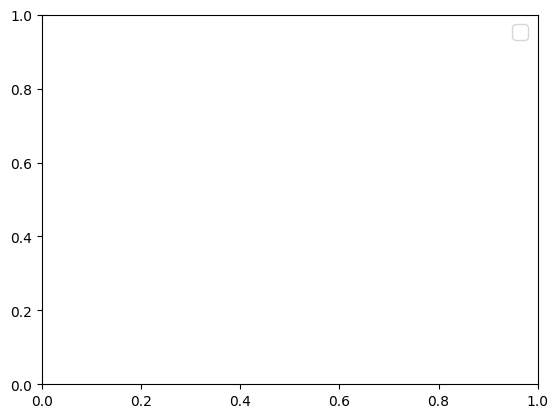

In [ ]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):

 plt.figure(figsize=(10, 7))
#plotting training data in blue
 plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
#plotting testing data in green
 plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

 #are tehre predictions
 if predictions is not None:
  #plot the predictions if they exist
  plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")


  #show the legend
plt.legend(prop={"size": 14});

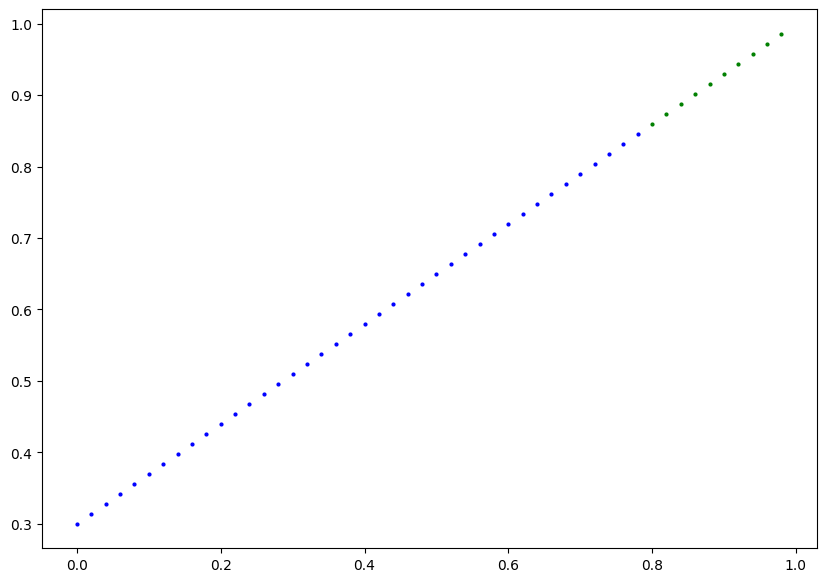

In [ ]:
plot_predictions();

## 2. Build model
Out First PyTorch model

what our model does:
* start with random values (weight and bias)
* lok at training data nad adjust the random values to beter represent (ro get close to ) the ideal values (the weight and bais values we use to create the data)

How does it do so:

Through 2 main algorithm:
* Gradient descent
* Backpropagation

In [ ]:
from torch import nn
#create linear regression model class
class LinearRegressionModel(nn.Module):    # <- almost everything in PyTOrch inherits from nn.Module
  def __init__ (self):
    super().__init__()
    #here in self.weights and self.bias are defined because we are using our own data
    #Initialize the model parameters
    self.weights  = nn.Parameter(torch.randn(1,
                                             requires_grad=True,
                                             dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad=True, #pytorch will track gradients of thie specific parameter to use with torch.autograd and gradient descent
                                         dtype=torch.float))

    #forward method to define the computation in the model
  def forward(self, x: torch.Tensor) -> torch.Tensor: # <- X is the input data
    return self.weights * x + self.bias # thi sis linear regression formula
# any subclass of nn.module need to define a forward()
#foward is responsible for computations of nn.module

# Pytorch model building essentials

* torch.nn = contains all of the buildings for computations graphs (a neural network can be considred a computation graph)
* torch.nn.Parameter = what parameters should our model try and learn, often a PyTorch layer from torch.nn will set these for us
* torch.nn.Module = the base class for all neural network modules, if you subclass it, you should overwrite forward()
* torch.optim - this is where the optimizer of pytorch live, they will help with gradient descent
* def forward() = All nn.Module subclass require you to overwrite forward(), this method defined what happens in forward computation

# Checking the content of our PyTorch model

we can check our model parameters using: .parameters()

In [ ]:
#create a random seed
torch.manual_seed(42) # we did this cause we did .randn earlier
# if we ont use random seed then it's gonna show different values every time of our parameters

#create an instance of the model ( this is a subclass of nn.Module)
model_0 = LinearRegressionModel()

#checking our parameters
list(model_0.parameters())#we used list just becuase we wanted to see them in list it's optional



[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
# List name parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

# Making predictions using torch.inference_mode()

To check our model's predictive power, let's see how well it preicts 'y_test' based on X_test
when we pass data through our model, it's going to rune it through the forward() method

In [ ]:
# make predictions iwth model
with torch.inference_mode():
  y_preds = model_0(X_test)

# can also use no_grad instead of inference_mode, result will be same, however inference_mode() is preferred
# with torch.no_grad():
 # y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

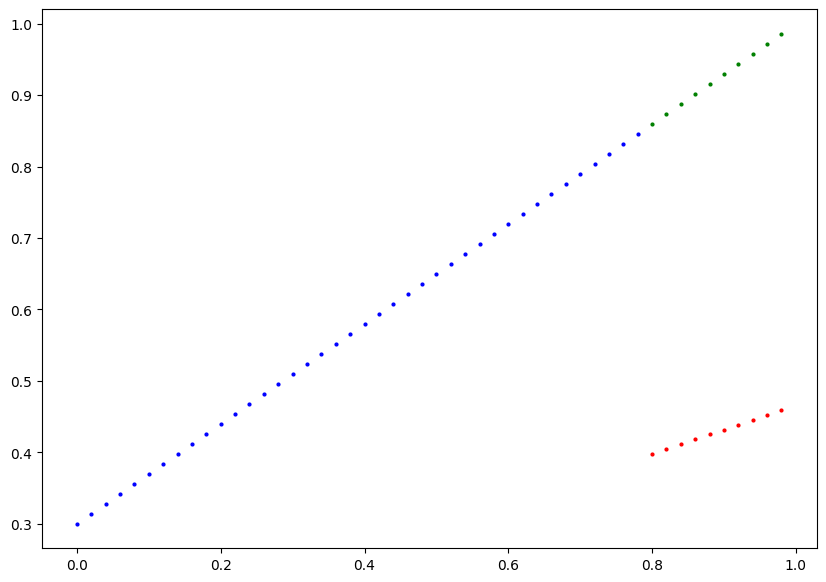

In [ ]:
plot_predictions(predictions=y_preds)

#  3. Training model:

The whole idea of training is for a model to move from some *unknown* parameters (these may be random) to some known parameters

or in other words form a poor prepresentation of the data to a better representation of the data

one way to measure how poor or how wrong your model's predictions is to measure loss functions

* Note: loss functions may also be called cost functions or cretierion in different areas.

**Loss function:**
A function to measure how wrong our model's predictions are to the ideal outputs; the lower it is the better

**Optimizer:** takes into account the loss of a model and adjust the mode's parametrs (example here: weight & bias) to improve the loss function.

And specifically for Pytorch, we need:
* A Training loop
* A testing loop

In [ ]:
# Setting up the loss function
loss_fn = nn.L1Loss()

# setting an optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),
                                lr=0.01) #lr = learning rate = possibly the most important hyperparameter we can set
                                # lr defined how big / small the optimizer changes the parameters with each step



q: Which lost function and optimizer should i use?
a: it vary depend on the problem
for example, for a regressoin problem like ours a loss fucntion of nn.L1Loss() and an optimizer like torch.optim.SGD() will suffic

for a classification problem like classifying whether a photo is of a dog or cat, loss function of nn.BCELoss()

## Building  a training loop (and a testing loop) in PyTorch

A couple of things we need in a training loop:

0. Loop through the data
1. Forward pass (this involves data moving through our model's forward() function) to make predictions on data - also called Forward Propogation
2. calculate the loss ( compare forward pass preictions to ground truth labels)
3. optimizer zero grad
4. Loss backward - move backwards through the network to calculate the gradients of each of the parameters of our model with respect to the loss. **(Backpropogation)**
5. Optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss **(gradient descent)**

In [ ]:
# an epcch is one loop through the data
# this is a hyperparameters because we set it ourselves
epochs = 150

# Track different values
epoch_count = []
loss_values = []
test_loss_values = []

### Training

#0 loop through the data
for epochs in range(epochs):
  # set the model to trianing mode
  model_0.train() #train mode in PyTorch sets all parametrs that require gradient to require  graidents

  # 1. Forward pass
  y_pred = model_0(X_train)

  # 2. Calculate the loss
  loss = loss_fn(y_pred, y_train)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. perform backpropogation on the loss with respect to the parametrs or the model
  loss.backward()

  # 5. step the optmizer (perform gradient descent)
  optimizer.step()

  ### Testing
  model_0.eval() ## turns off different setting in the model not needed evaluation/ testing
  with torch.inference_mode(): ## turns off tradient trackign and a couple more things bts
    # 1. forward pass
    test_pred = model_0(X_test)

    # 2. calculate the loss
    test_loss = loss_fn(test_pred, y_test)
  #print out what's happening
  if epochs % 10 == 0:
    epoch_count.append(epochs)
    loss_values.append(loss)
    test_loss_values.append(test_loss)
    print(f"Epoch: {epochs} | Test: {loss} ] Test Loss: {test_loss}")

  # print out model state_dict()
  print(model_0.state_dict())


Epoch: 0 | Test: 0.31288138031959534 ] Test Loss: 0.48106518387794495
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})
OrderedDict({'weights': tensor([0.3445]), 'bias': tensor([0.1488])})
OrderedDict({'weights': tensor([0.3484]), 'bias': tensor([0.1588])})
OrderedDict({'weights': tensor([0.3523]), 'bias': tensor([0.1688])})
OrderedDict({'weights': tensor([0.3562]), 'bias': tensor([0.1788])})
OrderedDict({'weights': tensor([0.3601]), 'bias': tensor([0.1888])})
OrderedDict({'weights': tensor([0.3640]), 'bias': tensor([0.1988])})
OrderedDict({'weights': tensor([0.3679]), 'bias': tensor([0.2088])})
OrderedDict({'weights': tensor([0.3718]), 'bias': tensor([0.2188])})
OrderedDict({'weights': tensor([0.3757]), 'bias': tensor([0.2288])})
Epoch: 10 | Test: 0.1976713240146637 ] Test Loss: 0.3463551998138428
OrderedDict({'weights': tensor([0.3796]), 'bias': tensor([0.2388])})
OrderedDict({'weights': tensor([0.3835]), 'bias': tensor([0.2488])})
OrderedDict({'weights': tensor([0

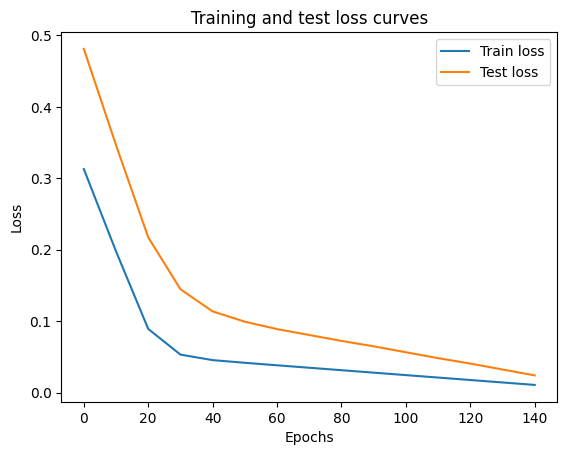

In [ ]:
import numpy as np
# plot the lost curve
#here we convert loss values form tensor to numpy because matplotlib works with numpy
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [ ]:
with torch.inference_mode():
  y_preds_new = model_0(X_test)

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6638])), ('bias', tensor([0.3153]))])

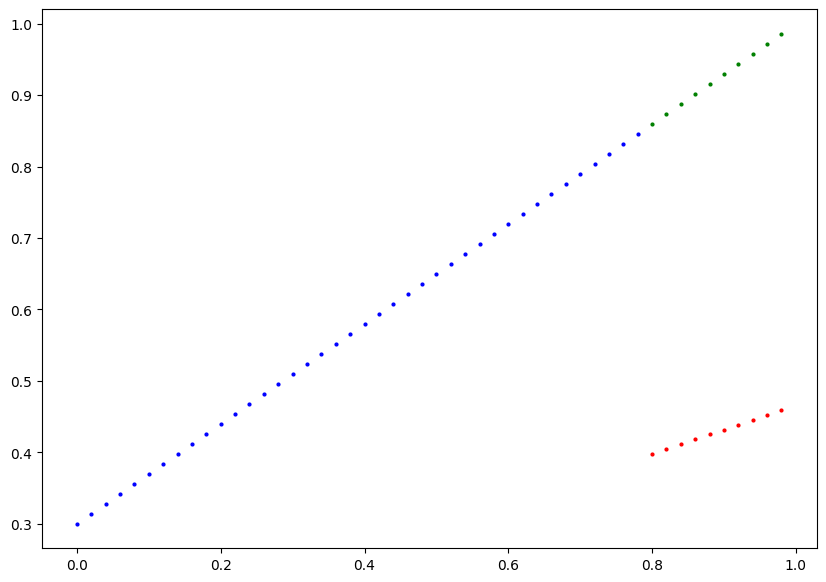

In [ ]:
plot_predictions(predictions=y_preds);

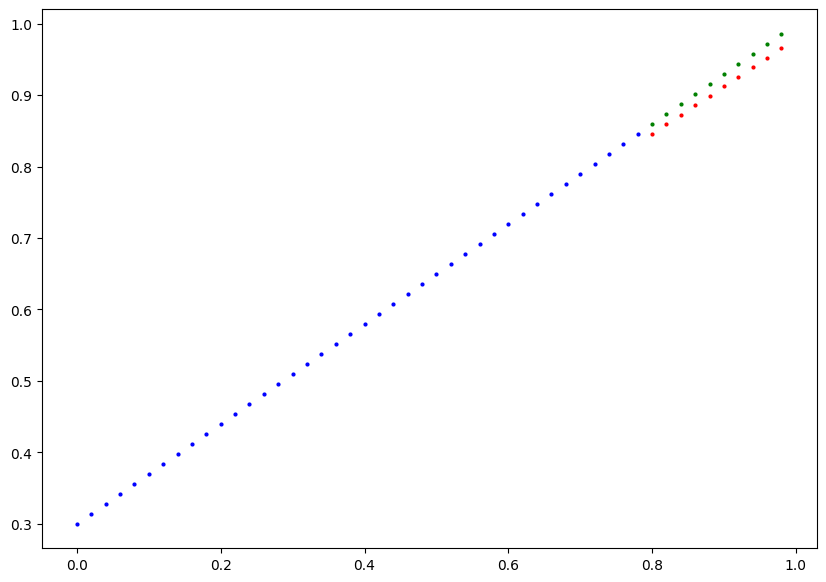

In [ ]:
plot_predictions(predictions=y_preds_new);

# Saving a model in PyTorch
there are about three main methods for saving a model:
1. 'torch.save()' = allows you save a PyTorch object in Python's pickle format
2. 'torch.load()' = allow you to save a PyTorch object
3. 'torch.nn.Module.load_state_dict()' = this allow to load a mode's saved state dictionary

In [ ]:
#saving our pytorch model
from pathlib import Path
 # 1. create model directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

#2.  Create model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

MODEL_SAVE_PATH

# 3. saving the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH)
#


Saving model to: models/01_pytorch_workflow_model_0.pth


#Loading a PyTorch model

since we save our model's state_dict() rather than entire model, we'll create a new instance of our model


In [ ]:
# to load in  a saved state_dict we have to instantiate a new instance of our model class
loaded_model_0 = LinearRegressionModel()

#load the saved state dict of model_0
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [ ]:
# make some predictions with our loaded model
loaded_model_0.eval()
with torch.inference_mode():
  loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds

tensor([[0.8464],
        [0.8596],
        [0.8729],
        [0.8862],
        [0.8995],
        [0.9127],
        [0.9260],
        [0.9393],
        [0.9526],
        [0.9659]])

In [ ]:
#make some model preds
model_0.eval()
with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds

tensor([[0.8464],
        [0.8596],
        [0.8729],
        [0.8862],
        [0.8995],
        [0.9127],
        [0.9260],
        [0.9393],
        [0.9526],
        [0.9659]])

In [ ]:
y_model == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])